In [27]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

In [35]:
class ParcelDeliveryEnv(gym.Env):
    def __init__(self):
        super(ParcelDeliveryEnv, self).__init__()
        self.grid_rows = 5
        self.grid_cols = 5
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.grid_rows * self.grid_cols)

        # starting point of the drone
        self.start_pos = np.array([0, 0])
        self.drone_pos = self.start_pos.copy()
        self.parcel_location = np.array([2, 2])
        self.delivery_house = np.array([0, 3])
        self.wind_zones = [np.array([4, 1]), np.array([2, 4])]
        self.no_fly_zone = np.array([4, 3])
        self.low_battery_zone = np.array([3, 1])
        self.has_parcel = False

    def reset(self, seed=None, options=None):
        self.drone_pos = self.start_pos.copy()
        self.has_parcel = False
        state = self._pos_to_state(self.drone_pos)
        return state, {}


    def step(self, action):
        if action == 0:
            self.drone_pos[1] += 1
        elif action == 1:
            self.drone_pos[1] -= 1
        elif action == 2:
            self.drone_pos[0] -= 1
        elif action == 3:
            self.drone_pos[0] += 1

        self.drone_pos[0] = np.clip(self.drone_pos[0], 0, self.grid_cols - 1)
        self.drone_pos[1] = np.clip(self.drone_pos[1], 0, self.grid_rows - 1)
        reward = -1
        terminated = False

        if np.array_equal(self.drone_pos, self.parcel_location) and not self.has_parcel:
            self.has_parcel = True
            reward += 10

        if any(np.array_equal(self.drone_pos, w) for w in self.wind_zones):
            reward -= 10

        if np.array_equal(self.drone_pos, self.low_battery_zone):
            reward -= 5

        if np.array_equal(self.drone_pos, self.no_fly_zone):
            reward -= 15

        if np.array_equal(self.drone_pos, self.delivery_house) and self.has_parcel:
            reward += 25
            terminated = True

        state = self._pos_to_state(self.drone_pos)
        return state, reward, terminated, False, {}


    def render(self):
        grid = np.zeros((self.grid_rows, self.grid_cols), dtype=object)
        for r in range(self.grid_rows):
            for c in range(self.grid_cols):
                grid[r, c] = " . "

        grid[self.parcel_location[1], self.parcel_location[0]] = " PK "
        grid[self.delivery_house[1], self.delivery_house[0]] = " DH "

        for wz in self.wind_zones:
            grid[wz[1], wz[0]] = " WZ "

        grid[self.no_fly_zone[1], self.no_fly_zone[0]] = " NF "
        grid[self.low_battery_zone[1], self.low_battery_zone[0]] = " LB "
        grid[self.drone_pos[1], self.drone_pos[0]] = " DR "

        plt.figure(figsize=(6, 6))
        plt.imshow(np.zeros((self.grid_rows, self.grid_cols)), cmap="gray_r")
        plt.xticks(range(self.grid_cols))
        plt.yticks(range(self.grid_rows))
        plt.grid(True)

        for r in range(self.grid_rows):
            for c in range(self.grid_cols):
                plt.text(c, r, grid[r, c], ha="center", va="center", fontsize=15)

        plt.title("Parcel delivery drone grid world")
        plt.show()


    def _pos_to_state(self, pos):
        return pos[1] * self.grid_cols + pos[0]

In [36]:
def chooseaction(qtable, state, eps):
    if np.random.rand() < eps:
        return np.random.randint(0, 4)
    # greedychoice
    return np.argmax(qtable[state])

In [37]:
def runsarsa(env, episodes, stepmax, learnrate, discountrate,
             eps, epsdrop, epsmin):

    numstates = env.observation_space.n
    numacts = env.action_space.n

    qtable = np.zeros((numstates, numacts))

    allrewards = []
    alleps = []

    for ep in range(episodes):

        state, info = env.reset()
        act = chooseaction(qtable, state, eps)

        totalreward = 0

        for step in range(stepmax):

            nextstate, reward, done, trunc, info = env.step(act)
            nextact = chooseaction(qtable, nextstate, eps)

            nowvalue = qtable[state, act]
            nextvalue = qtable[nextstate, nextact]

            newvalue = nowvalue + learnrate * (reward + discountrate * nextvalue - nowvalue)
            qtable[state, act] = newvalue

            totalreward += reward

            state = nextstate
            act = nextact

            if done:
                break

        eps = max(epsmin, eps * epsdrop)

        allrewards.append(totalreward)
        alleps.append(eps)

    return qtable, allrewards, alleps

In [38]:
env = ParcelDeliveryEnv()
episodes = 300
stepmax = 50
learnrate = 0.2
discountrate = 0.9
eps = 1.0
epsdrop = 0.99
epsmin = 0.05

print("Initial Q Table:")
print(np.zeros((env.observation_space.n, env.action_space.n)))

qtable, allrewards, alleps = runsarsa(
    env,
    episodes,
    stepmax,
    learnrate,
    discountrate,
    eps,
    epsdrop,
    epsmin
)

print("Trained Q Table:")
print(qtable)

Initial Q Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Trained Q Table:
[[ 5.16463522e+00 -4.60750902e+00 -3.46750346e+00 -4.48410741e+00]
 [-4.20801362e+00 -4.30231201e+00 -4.23478161e+00 -4.12269746e+00]
 [-3.91384996e+00 -4.01912719e+00 -3.97540125e+00 -4.17883797e+00]
 [-6.28140743e+00 -4.21026167e+00 -3.95058468e+00 -3.91616140e+00]
 [-1.09458286e+01 -3.91264866e+00 -3.80284627e+00 -3.66179776e+00]
 [ 1.05235157e+01 -4.41990561e+00 -3.17245262e-01 -3.64049872e+00]
 [-1.89056717e+00 -4.12629501e+00 -4.13433370e+00 -3.73847382e+00]
 [-5.01542799e-01 -4.04345719e+00 -4.05480558e+00 -8.28671670e+00]
 [-4.46881385e+00 -3.75861158e+00 -2.31941082e+00 -1.0

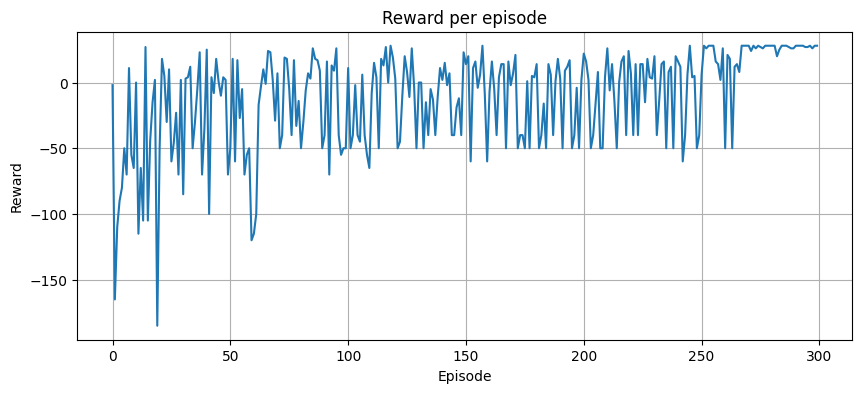

In [39]:
plt.figure(figsize=(10,4))
plt.plot(allrewards)
plt.title("Reward per episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

The reward curve tells us that:
Large negative values in early episodes
Steady improvement around episode 40
Mostly positive rewards after episode 150
Smooth performance stabilization
This indicates agent is correctly learning the pickup-and-delivery path while avoiding hazards.

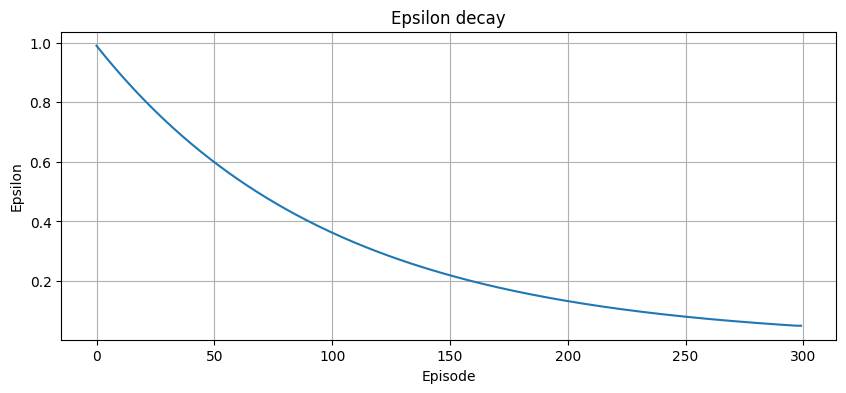

In [40]:
plt.figure(figsize=(10,4))
plt.plot(alleps)
plt.title("Epsilon decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid()
plt.show()

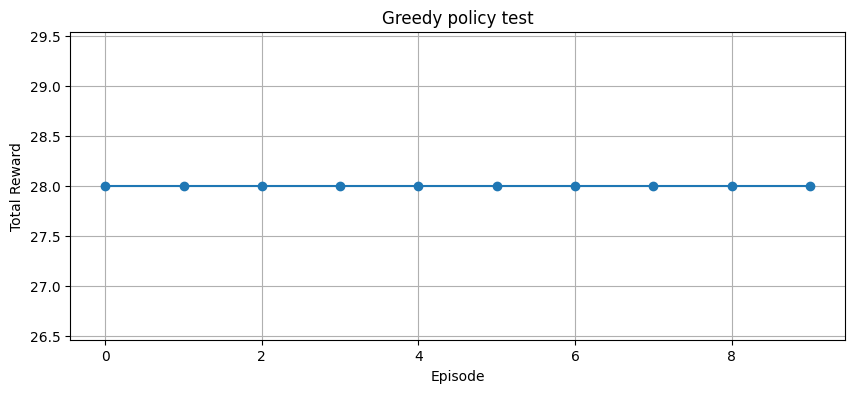

Greedy Rewards: [28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


In [41]:
def rungreedy(env, qtable, episodes=10, stepmax=50):
    alltest = []
    for ep in range(episodes):
        state, info = env.reset()
        totalreward = 0
        for step in range(stepmax):
            act = np.argmax(qtable[state])
            nextstate, reward, done, trunc, info = env.step(act)
            totalreward += reward
            state = nextstate
            if done:
                break
        alltest.append(totalreward)
    return alltest


greedylist = rungreedy(env, qtable)

plt.figure(figsize=(10,4))
plt.plot(greedylist, marker='o')
plt.title("Greedy policy test")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid()
plt.show()

print("Greedy Rewards:", greedylist)

Agent SARSA commenced without knowledge and learned iteratively which moves increased long-term reward.
The reward curve confirmed that, as episodes progressed, the agent moved away from hazard zones toward a stable delivery path.
Epsilon decay allowed the agent to explore early and exploit knowledge later.
The final Q table produced a policy that accomplished the pickup-and-delivery sequence in every episode under greedy evaluation.
A constant greedy reward of +28 across test episodes exhibits that the policy has converged and the agent behaves optimally on this environment.

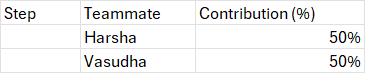